# Temporal Trend Analysis

Covers total volume trajectory, cluster-level growth/decline, day-of-week patterns, failure rate over time, and language mix. Forecasting models (Prophet, ETS, ARIMA) are in `07_forecasting.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sp_stats
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

_nb_file = globals().get('__vsc_ipynb_file__', None)
if _nb_file:
    REPO_ROOT = Path(_nb_file).parent.parent
else:
    _cwd = Path.cwd()
    REPO_ROOT = _cwd if (_cwd / 'gcp_config.py').exists() else _cwd.parent

OUT_DIR = REPO_ROOT / 'data'
OUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUT_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = OUT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(REPO_ROOT))
from gcp_config import PROJECT_ID, bq_table
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

df_weekly = client.query(f"""
    SELECT
        week_start AS week,
        total_conversations,
        escalated_count,
        negative_ratings,
        positive_ratings,
        headline_failures,
        headline_failure_rate_pct,
        escalation_rate_pct,
        avg_client_messages
    FROM `{bq_table('weekly_volume')}`
    ORDER BY week_start
""").to_dataframe()
df_weekly['week']  = pd.to_datetime(df_weekly['week'])
df_weekly['month'] = df_weekly['week'].dt.to_period('M').dt.start_time

df_cluster_trends = client.query(f"""
    SELECT
        week_start AS week,
        cluster_id,
        chunk_count,
        conversation_count,
        escalated_count,
        negative_count,
        headline_failures
    FROM `{bq_table('chunk_cluster_trends')}`
    ORDER BY cluster_id, week_start
""").to_dataframe()
df_cluster_trends['week'] = pd.to_datetime(df_cluster_trends['week'])

df = client.query(f"""
    SELECT
        conversation_id,
        DATE(conversation_start_date) AS conversation_date,
        client_message_count,
        rating_score,
        detected_language
    FROM `{bq_table('conversation_docs')}`
""").to_dataframe()
df['conversation_date'] = pd.to_datetime(df['conversation_date'])
df['week']  = df['conversation_date'].dt.to_period('W').dt.start_time
df['month'] = df['conversation_date'].dt.to_period('M').dt.start_time
df['dow']   = df['conversation_date'].dt.day_name()
df['negative'] = df['rating_score'] == -1

print(f"Chunk pipeline: {len(df):,} conversations | {df_cluster_trends.cluster_id.nunique()} clusters | "
      f"{df.conversation_date.min().date()} → {df.conversation_date.max().date()}")
print(f"Weekly volume: {len(df_weekly)} weeks")
print(f"Cluster trends: {len(df_cluster_trends)} rows ({df_cluster_trends.cluster_id.nunique()} clusters)")

_rated = (df['rating_score'] != 0).sum()
print(f"\nRated conversations (👍 or 👎): {_rated:,} ({100 * _rated / len(df):.1f}% of all).")
print("  — Section 4 negative-rate plot uses neg/(neg+pos) — **rated-only** denominator.")
print("  — Headline 7.5% failure (T1∪T2) uses **all** conversations — not comparable to that curve.")

Chunk pipeline: 46,445 conversations | 24 clusters | 2025-05-01 → 2025-11-29
Weekly volume: 31 weeks
Cluster trends: 744 rows (24 clusters)

Rated conversations (👍 or 👎): 3,287 (7.1% of all).
  — Section 4 negative-rate plot uses neg/(neg+pos) — **rated-only** denominator.
  — Headline 7.5% failure (T1∪T2) uses **all** conversations — not comparable to that curve.


In [2]:
titles_df = client.query(f"""
    SELECT cluster_id, cluster_title
    FROM `{bq_table('chunk_cluster_descriptions')}`
    ORDER BY cluster_id
""").to_dataframe()
titles_dict = dict(zip(titles_df['cluster_id'], titles_df['cluster_title']))
print(f"Loaded {len(titles_df)} cluster titles")

Loaded 24 cluster titles


## 1. Total conversation volume over time

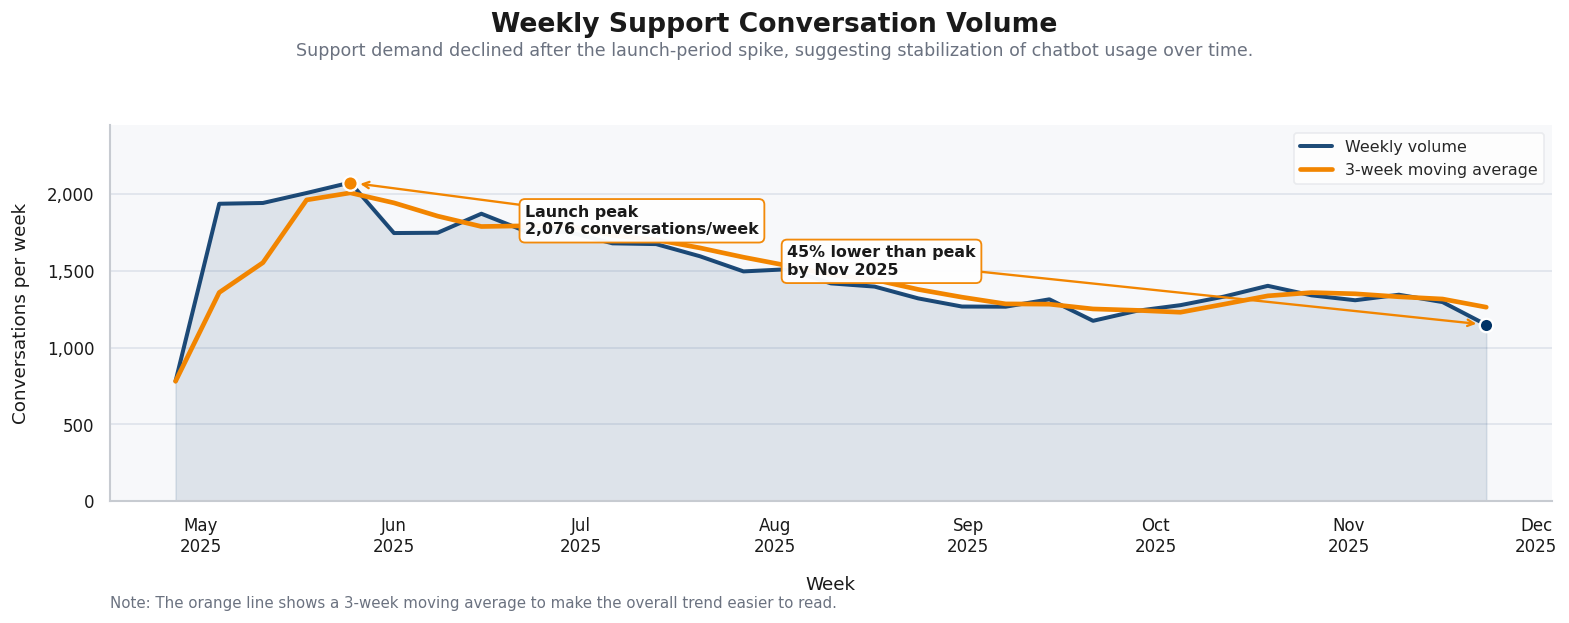

Peak: 2,076/week on 2025-05-25 | Last: 1,149/week on 2025-11-23 | Decline: 45%


In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd

navy = '#003366'
orange = '#F28500'
dark = '#1A1A1A'
grey = '#6B7280'
light_grey = '#F7F8FA'
grid_grey = '#D9DEE7'
white = '#FFFFFF'

df_w = df_weekly.sort_values('week').copy()
df_w['week'] = pd.to_datetime(df_w['week'])
df_w['rolling_3w'] = df_w['total_conversations'].rolling(3, min_periods=1).mean()

peak_row = df_w.loc[df_w['total_conversations'].idxmax()]
peak_week = peak_row['week']
peak_val = int(peak_row['total_conversations'])

last_week = df_w['week'].iloc[-1]
last_val = int(df_w['total_conversations'].iloc[-1])

pct_drop = round((peak_val - last_val) / peak_val * 100)

fig, ax = plt.subplots(figsize=(13.5, 5.4))
fig.patch.set_facecolor(white)
ax.set_facecolor(light_grey)

fig.subplots_adjust(top=0.80, bottom=0.22, left=0.09, right=0.98)

fig.suptitle('Weekly Support Conversation Volume',
             fontsize=16, fontweight='bold', color=dark, y=0.975)

fig.text(0.5, 0.915,
         'Support demand declined after the launch-period spike, suggesting stabilization of chatbot usage over time.',
         fontsize=10.5, color=grey, ha='center', va='center')

ax.fill_between(df_w['week'], df_w['total_conversations'],
                color=navy, alpha=0.10, zorder=1)

ax.plot(df_w['week'], df_w['total_conversations'],
        color=navy, lw=2.4, alpha=0.88, zorder=3, label='Weekly volume')

ax.plot(df_w['week'], df_w['rolling_3w'],
        color=orange, lw=2.8, zorder=4, label='3-week moving average')

ax.scatter(peak_week, peak_val, s=75, color=orange,
           edgecolor=white, linewidth=1.4, zorder=5)

ax.scatter(last_week, last_val, s=65, color=navy,
           edgecolor=white, linewidth=1.4, zorder=5)

ax.set_ylim(0, df_w['total_conversations'].max() * 1.18)

ax.annotate(f'Launch peak\n{peak_val:,} conversations/week',
            xy=(peak_week, peak_val),
            xytext=(peak_week + pd.Timedelta(weeks=4), peak_val * 0.88),
            fontsize=9.5, color=dark, fontweight='bold',
            ha='left', va='center',
            arrowprops=dict(arrowstyle='->', color=orange, lw=1.4,
                            shrinkA=0, shrinkB=6),
            bbox=dict(boxstyle='round,pad=0.35', fc=white,
                      ec=orange, lw=1.1, alpha=0.96),
            zorder=6)

ax.annotate(f'{pct_drop}% lower than peak\nby {last_week.strftime("%b %Y")}',
            xy=(last_week, last_val),
            xytext=(last_week - pd.Timedelta(weeks=16), last_val * 1.36),
            fontsize=9.5, color=dark, fontweight='bold',
            ha='left', va='center',
            arrowprops=dict(arrowstyle='->', color=orange, lw=1.4,
                            shrinkA=0, shrinkB=6),
            bbox=dict(boxstyle='round,pad=0.35', fc=white,
                      ec=orange, lw=1.1, alpha=0.96),
            zorder=6)

ax.set_xlabel('Week', fontsize=11, color=dark, labelpad=12)
ax.set_ylabel('Conversations per week', fontsize=11, color=dark, labelpad=10)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.tick_params(axis='both', labelsize=10, colors=dark)
ax.grid(axis='y', color=grid_grey, lw=0.9, alpha=0.9)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#C7CBD1')
ax.spines['bottom'].set_color('#C7CBD1')

ax.legend(loc='upper right', frameon=True, facecolor=white,
          edgecolor='#E5E7EB', fontsize=9.5)

fig.text(0.09, 0.055,
         'Note: The orange line shows a 3-week moving average to make the overall trend easier to read.',
         fontsize=9, color=grey, ha='left')

plt.savefig(FIGURES_DIR / 'weekly_volume_capstone_style.png',
            dpi=300, bbox_inches='tight', facecolor=white)
plt.show()

print(f'Peak: {peak_val:,}/week on {peak_week.date()} | '
      f'Last: {last_val:,}/week on {last_week.date()} | '
      f'Decline: {pct_drop}%')

## 2. Cluster volume trends

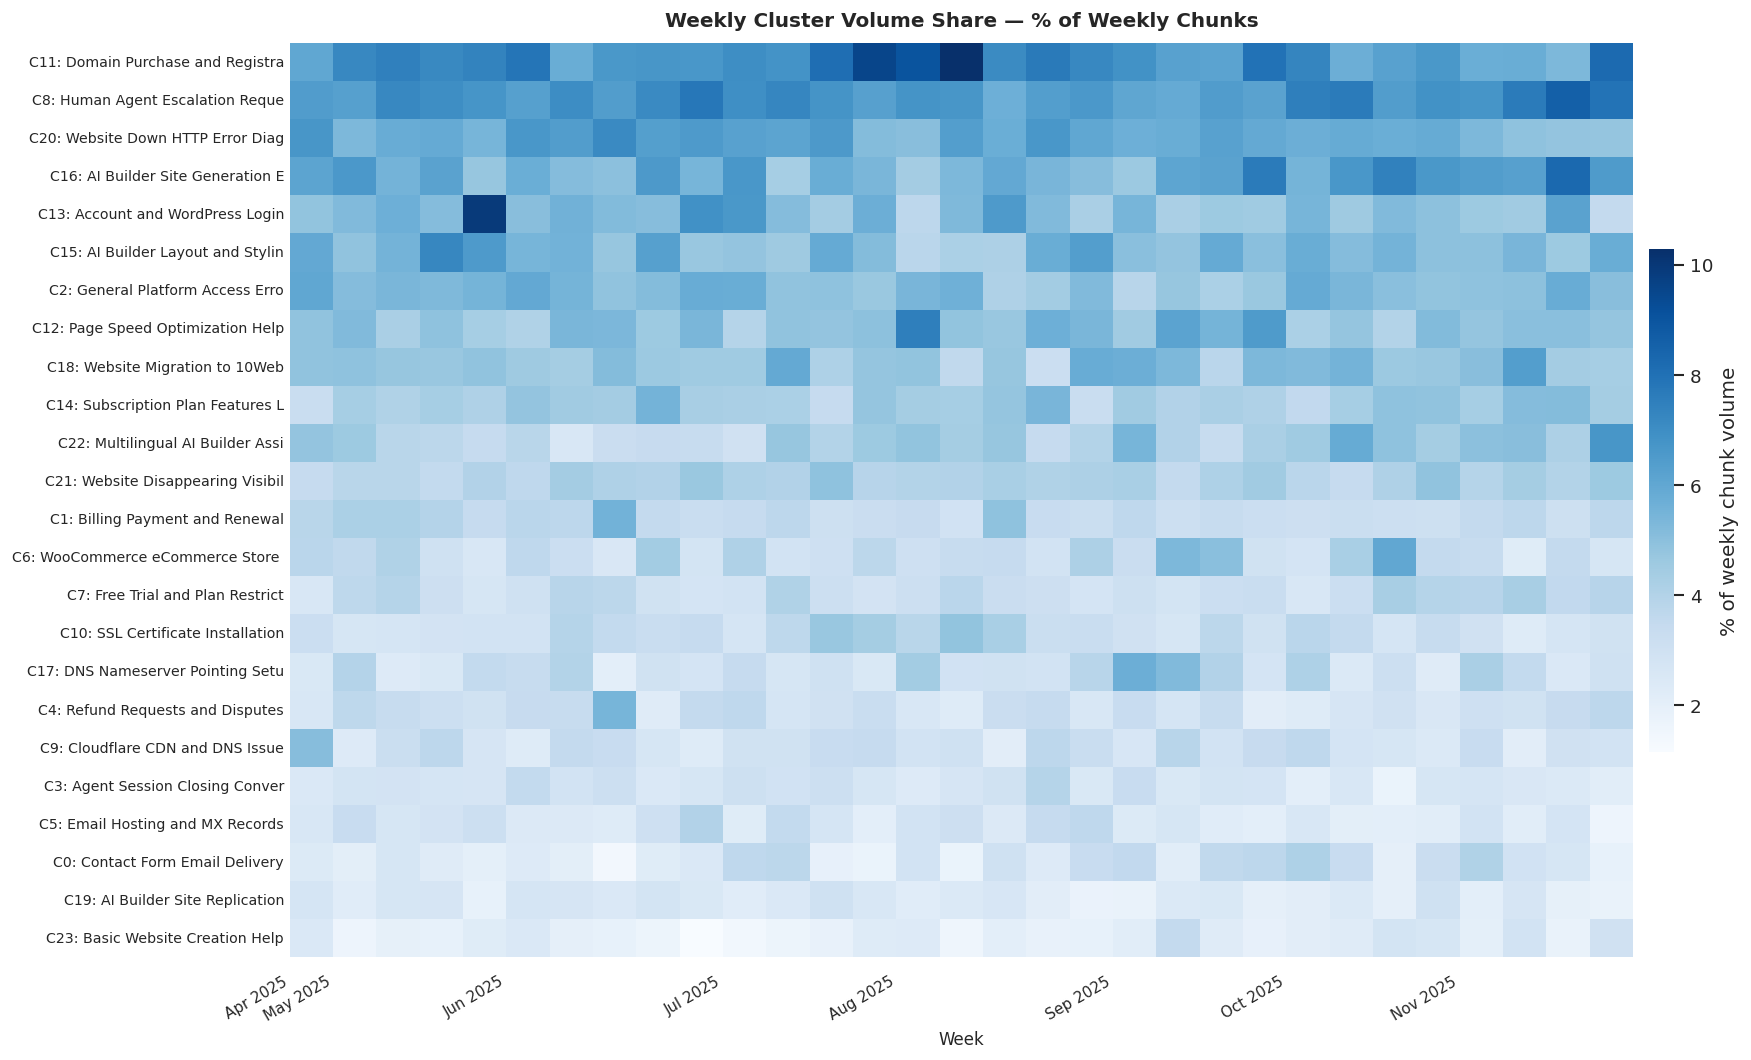

Saved: cluster_share_heatmap.png
Cluster trend summary (by chunk volume):
 cluster_id  total_chunks  slope_per_week  r_squared  p_value       trend
         22          6244           0.074      0.014   0.5267    stable →
          0          3954           0.048      0.008   0.6381    stable →
         23          3126           0.019      0.003   0.7840    stable →
         16          8733          -0.116      0.018   0.4730    stable →
         17          4864          -0.127      0.033   0.3309    stable →
          7          4979          -0.131      0.053   0.2143    stable →
          6          5210          -0.162      0.054   0.2099    stable →
         21          6063          -0.206      0.126   0.0501    stable →
         14          6548          -0.232      0.113   0.0647    stable →
         10          4942          -0.242      0.154   0.0293 declining ↓
          9          4485          -0.251      0.270   0.0028 declining ↓
         19          3564          -0.

In [4]:
pivot = df_cluster_trends.pivot(
    index='week', columns='cluster_id', values='chunk_count'
).fillna(0).astype(float)
pivot.index = pd.to_datetime(pivot.index)          # ensure DatetimeIndex
pivot = pivot.sort_index()

pivot_share = pivot.div(pivot.sum(axis=1), axis=0).mul(100)

sort_order  = pivot.sum().sort_values(ascending=False).index.tolist()
heat_data   = pivot_share[sort_order].T.astype(float)  # (clusters, weeks)

row_labels  = [
    f"C{int(c)}: {titles_dict.get(int(c), '')[:28]}"
    for c in sort_order
]

weeks = pivot.index
monthly_pos    = [i for i, w in enumerate(weeks)
                  if i == 0 or w.month != weeks[i - 1].month]
monthly_labels = [weeks[i].strftime('%b %Y') for i in monthly_pos]

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(
    heat_data,
    ax=ax,
    cmap='Blues',
    linewidths=0,
    yticklabels=row_labels,
    xticklabels=False,
    cbar_kws={'label': '% of weekly chunk volume', 'shrink': 0.55, 'pad': 0.01},
)
ax.set_xticks(monthly_pos)
ax.set_xticklabels(monthly_labels, rotation=30, ha='right', fontsize=9)
ax.set_title('Weekly Cluster Volume Share — % of Weekly Chunks',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Week', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8.5, length=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_share_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cluster_share_heatmap.png')

weeks_numeric = (pivot.index - pivot.index.min()).days.values
trend_rows = []
for cid in pivot.columns:
    y = pivot[cid].values
    slope, _, r, p, _ = sp_stats.linregress(weeks_numeric, y)
    trend_rows.append({
        'cluster_id'    : cid,
        'total_chunks'  : int(y.sum()),
        'slope_per_week': round(slope, 3),
        'r_squared'     : round(r**2, 3),
        'p_value'       : round(p, 4),
        'trend'         : ('growing ↑'  if slope >  0.05 and p < 0.05 else
                           'declining ↓' if slope < -0.05 and p < 0.05 else 'stable →'),
    })
trends_df = pd.DataFrame(trend_rows).sort_values('slope_per_week', ascending=False)
trends_df.to_csv(RESULTS_DIR / 'cluster_trends.csv', index=False)
print('Cluster trend summary (by chunk volume):')
print(trends_df.to_string(index=False))

weekly_total = pivot.sum(axis=1)
peak_week    = weekly_total.idxmax()
peak_vol     = int(weekly_total.max())
last_vol     = int(weekly_total.iloc[-1])
n_declining  = (trends_df['trend'].str.startswith('declining')).sum()
n_growing    = (trends_df['trend'].str.startswith('growing')).sum()

print(f'\nPeak chunk volume : week of {peak_week.strftime("%b %d, %Y")} ({peak_vol:,} chunks)')
print(f'Last week volume  : {weekly_total.index[-1].strftime("%b %d, %Y")} ({last_vol:,} chunks, '
      f'{100*(last_vol - peak_vol)/peak_vol:+.0f}% from peak)')
print(f'\n{n_declining}/24 clusters show declining chunk volume (p<0.05 OLS).')
print('Most declines reflect the post-launch volume normalization, not product degradation.')

_decl_top5 = (trends_df[trends_df['trend'].str.startswith('declining')]
              .sort_values('slope_per_week', ascending=True).head(5))
print('\nTop 5 declining clusters (steepest slope):')
for _, _r in _decl_top5.iterrows():
    _cid   = int(_r['cluster_id'])
    _title = titles_dict.get(_cid, f'C{_cid}')
    print(f"  C{_cid:2d}  {_title}  slope={_r['slope_per_week']:.3f}/wk  p={_r['p_value']:.4f}")


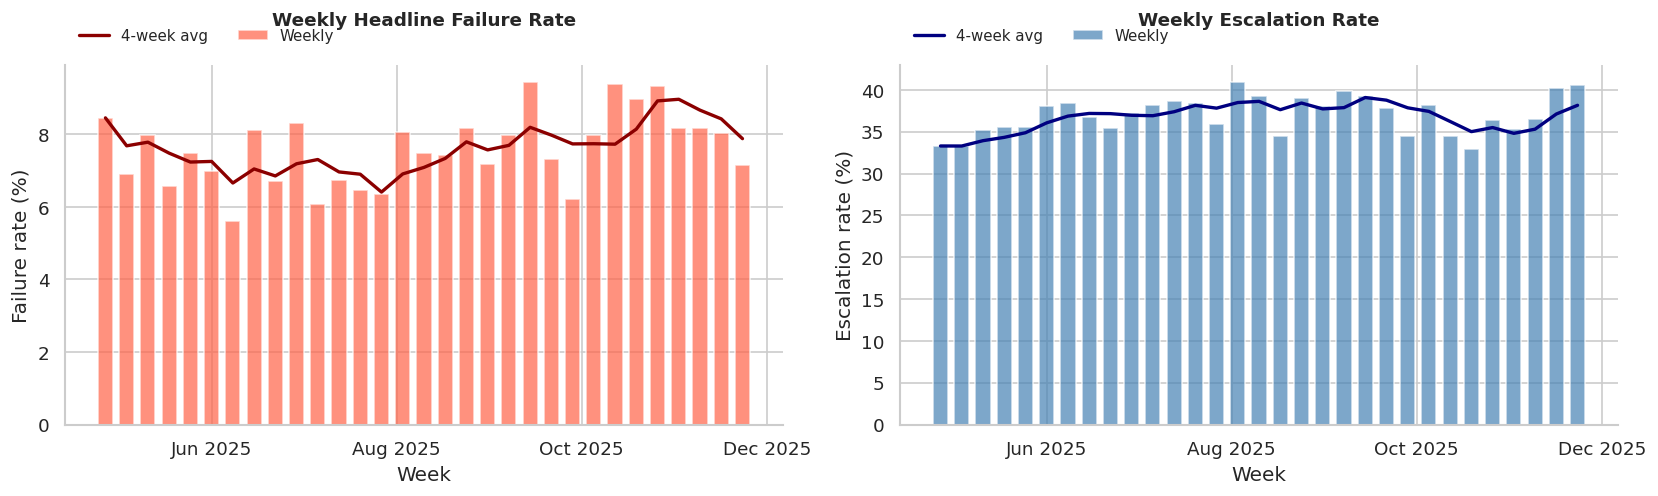

In [5]:
df_w = df_weekly.sort_values('week').copy()
df_w['week'] = pd.to_datetime(df_w['week'])

df_w['rolling_fail'] = df_w['headline_failure_rate_pct'].rolling(4, min_periods=1).mean()
df_w['rolling_esc']  = df_w['escalation_rate_pct'].rolling(4, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))

axes[0].bar(df_w['week'], df_w['headline_failure_rate_pct'],
            width=pd.Timedelta(days=5),
            alpha=0.7,
            color='tomato',
            label='Weekly')

axes[0].plot(df_w['week'], df_w['rolling_fail'],
             color='darkred',
             lw=2,
             label='4-week avg')

axes[0].set_title('Weekly Headline Failure Rate',
                  fontsize=11,
                  fontweight='bold',
                  pad=24)

axes[0].set_xlabel('Week')
axes[0].set_ylabel('Failure rate (%)')

axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

axes[0].legend(loc='upper left',
               bbox_to_anchor=(0, 1.14),
               ncol=2,
               frameon=False,
               fontsize=9)

sns.despine(ax=axes[0])

axes[1].bar(df_w['week'], df_w['escalation_rate_pct'],
            width=pd.Timedelta(days=5),
            alpha=0.7,
            color='steelblue',
            label='Weekly')

axes[1].plot(df_w['week'], df_w['rolling_esc'],
             color='navy',
             lw=2,
             label='4-week avg')

axes[1].set_title('Weekly Escalation Rate',
                  fontsize=11,
                  fontweight='bold',
                  pad=24)

axes[1].set_xlabel('Week')
axes[1].set_ylabel('Escalation rate (%)')

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

axes[1].legend(loc='upper left',
               bbox_to_anchor=(0, 1.14),
               ncol=2,
               frameon=False,
               fontsize=9)

sns.despine(ax=axes[1])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'failure_escalation_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 3. Day-of-week pattern

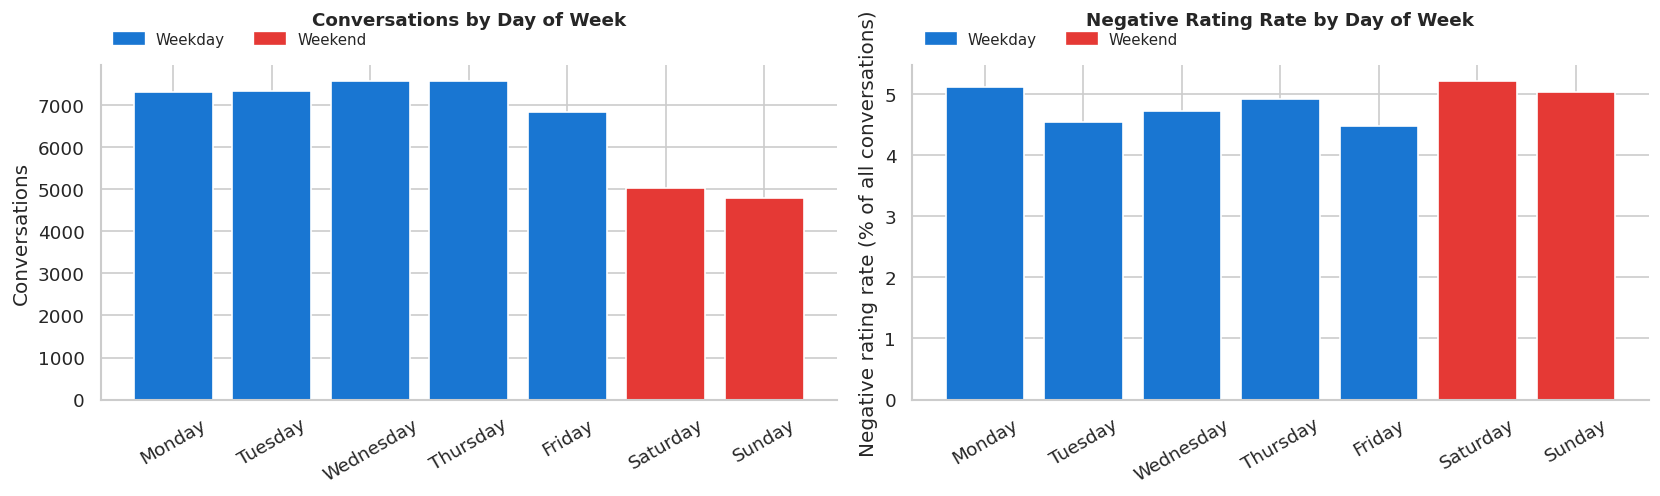


Day-of-week breakdown:
           count   pct  neg_rate_pct
dow                                 
Monday      7315  15.7          5.11
Tuesday     7335  15.8          4.54
Wednesday   7572  16.3          4.71
Thursday    7572  16.3          4.91
Friday      6833  14.7          4.48
Saturday    5029  10.8          5.21
Sunday      4789  10.3          5.03


In [6]:
from matplotlib.patches import Patch

dow_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

dow_counts = df.groupby('dow').size().reindex(dow_order)
n_weeks = df['week'].nunique()

bar_colors = ['#1976d2'] * 5 + ['#e53935'] * 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))

axes[0].bar(dow_counts.index,
            dow_counts.values,
            color=bar_colors)

axes[0].set_title('Conversations by Day of Week',
                  fontsize=11,
                  fontweight='bold',
                  pad=24)

axes[0].set_ylabel('Conversations')

axes[0].tick_params(axis='x', rotation=30)

axes[0].legend(handles=[
                    Patch(color='#1976d2', label='Weekday'),
                    Patch(color='#e53935', label='Weekend')
                ],
                loc='upper left',
                bbox_to_anchor=(0, 1.14),
                ncol=2,
                frameon=False,
                fontsize=9)

sns.despine(ax=axes[0])

dow_fail = df.groupby('dow')['negative'].mean().mul(100).reindex(dow_order)

axes[1].bar(dow_fail.index,
            dow_fail.values,
            color=bar_colors)

axes[1].set_title('Negative Rating Rate by Day of Week',
                  fontsize=11,
                  fontweight='bold',
                  pad=24)

axes[1].set_ylabel('Negative rating rate (% of all conversations)')

axes[1].tick_params(axis='x', rotation=30)

axes[1].legend(handles=[
                    Patch(color='#1976d2', label='Weekday'),
                    Patch(color='#e53935', label='Weekend')
                ],
                loc='upper left',
                bbox_to_anchor=(0, 1.14),
                ncol=2,
                frameon=False,
                fontsize=9)

sns.despine(ax=axes[1])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'dow_pattern.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('\nDay-of-week breakdown:')

print(
    dow_counts.to_frame('count').assign(
        pct=lambda d: (d['count'] / d['count'].sum() * 100).round(1),
        neg_rate_pct=dow_fail.round(2)
    )
)

## 4. Failure rate over time

Metric reconciliation (do not compare to headline 7.5% directly):
  Mean weekly headline_failure_rate_pct (all convs): 7.59%
  Mean weekly neg_rate among rated only            : 68.64%


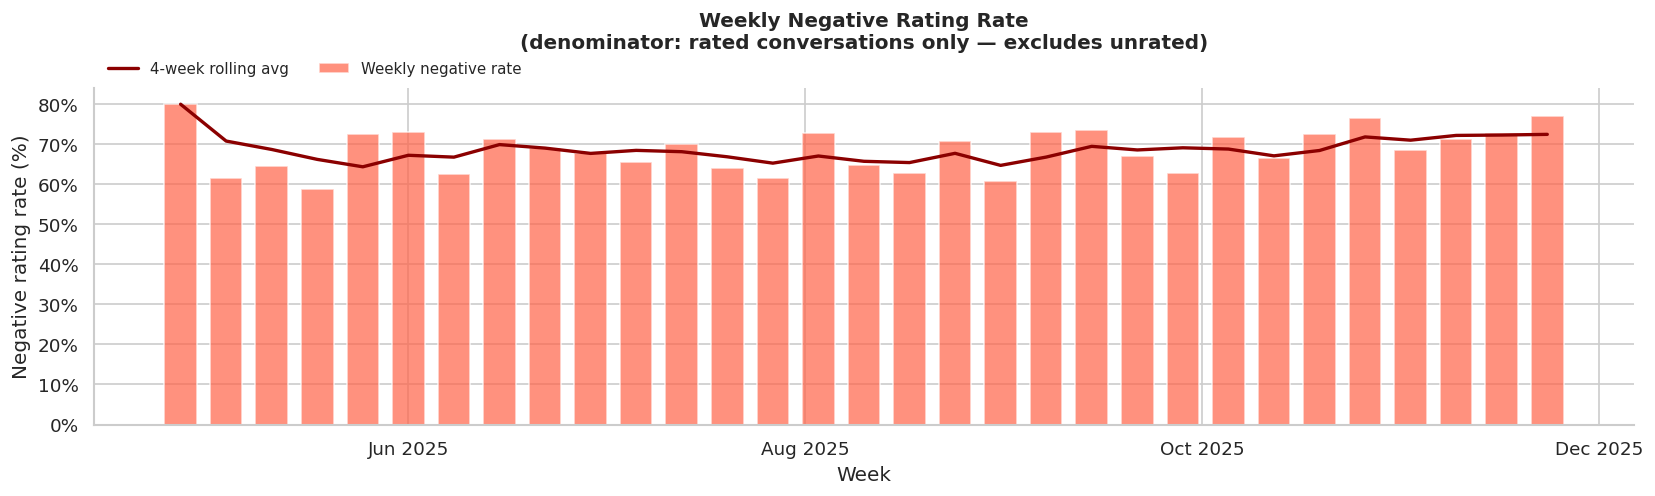

In [7]:
df_w = df_weekly.sort_values('week').copy()
rated_total = df_w['negative_ratings'] + df_w['positive_ratings']

df_w['neg_rate'] = 100 * df_w['negative_ratings'] / rated_total.replace(0, np.nan)
df_w['rolling_neg'] = df_w['neg_rate'].rolling(4, min_periods=1).mean()

print('Metric reconciliation (do not compare to headline 7.5% directly):')
print(f'  Mean weekly headline_failure_rate_pct (all convs): {df_w["headline_failure_rate_pct"].mean():.2f}%')
print(f'  Mean weekly neg_rate among rated only            : {df_w["neg_rate"].mean():.2f}%')

fig, ax = plt.subplots(figsize=(14, 4.3))

ax.bar(df_w['week'], df_w['neg_rate'],
       width=pd.Timedelta(days=5), alpha=0.7,
       color='tomato', label='Weekly negative rate')

ax.plot(df_w['week'], df_w['rolling_neg'],
        color='darkred', lw=2,
        label='4-week rolling avg')

ax.set_title('Weekly Negative Rating Rate\n'
             '(denominator: rated conversations only — excludes unrated)',
             fontsize=12, fontweight='bold', pad=24)

ax.set_xlabel('Week')
ax.set_ylabel('Negative rating rate (%)')

ax.yaxis.set_major_formatter(mticker.PercentFormatter())

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.legend(loc='upper left',
          bbox_to_anchor=(0, 1.12),
          ncol=2,
          frameon=False,
          fontsize=9)

sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(FIGURES_DIR / 'negative_rating_trend.png',
            dpi=300, bbox_inches='tight')

plt.show()

## 5. Chunk-weighted failure rate by cluster

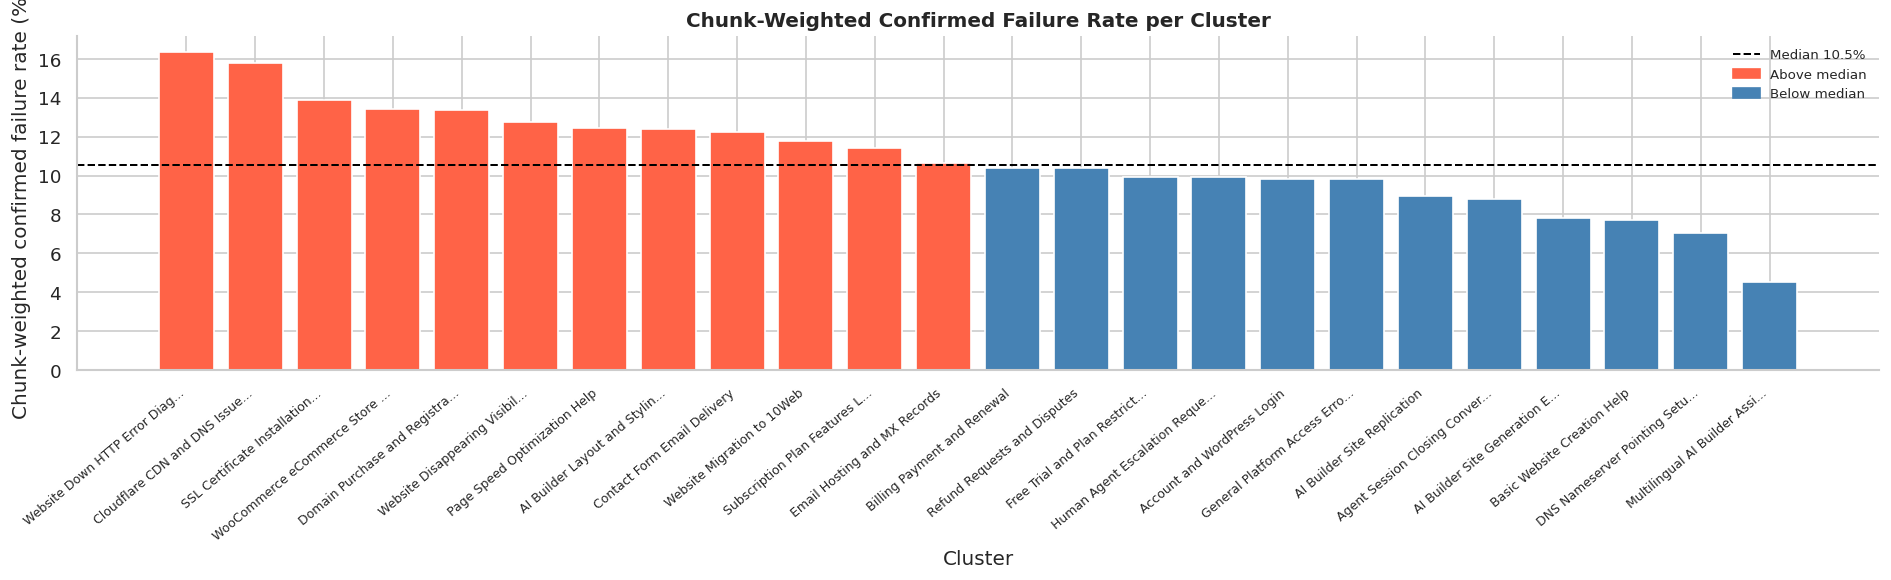

Cluster failure rates (worst first):
 cluster_id                          cluster_title  n_chunks  neg_rate  chunk_escalation_rate_pct
         20      Website Down HTTP Error Diagnosis      8774     16.34                      56.19
          9          Cloudflare CDN and DNS Issues      4491     15.79                      64.60
         10    SSL Certificate Installation Errors      4948     13.86                      57.80
          6      WooCommerce eCommerce Store Setup      5213     13.43                      44.33
         11       Domain Purchase and Registration     10609     13.37                      47.28
         21 Website Disappearing Visibility Issues      6068     12.76                      56.00
         12           Page Speed Optimization Help      7434     12.44                      67.33
         15          AI Builder Layout and Styling      7900     12.39                      61.92
          0            Contact Form Email Delivery      3956     12.23           

In [8]:
df_label = client.query(f"""
    SELECT cluster_id, n_chunks,
           COALESCE(chunk_confirmed_failure_rate_pct, 0) AS neg_rate,
           chunk_headline_failure_rate_pct,
           chunk_escalation_rate_pct
    FROM `{bq_table('chunk_cluster_label_table')}`
    ORDER BY chunk_confirmed_failure_rate_pct DESC NULLS LAST
""").to_dataframe()
df_label = df_label.merge(titles_df, on='cluster_id', how='left')
df_label['cluster_title'] = df_label['cluster_title'].fillna(df_label['cluster_id'].astype(str))

# Shorten labels to fit horizontal axis without overlap
df_label['short_label'] = df_label['cluster_title'].apply(
    lambda t: t[:28] + '...' if len(str(t)) > 28 else t
)

median_neg = df_label['neg_rate'].median()
colors = ['tomato' if r > median_neg else 'steelblue' for r in df_label['neg_rate']]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(df_label)), df_label['neg_rate'], color=colors)
ax.set_xticks(range(len(df_label)))
ax.set_xticklabels(df_label['short_label'], rotation=40, ha='right', fontsize=7.5)
ax.axhline(median_neg, color='black', linestyle='--', lw=1.2, label=f'Median {median_neg:.1f}%')
ax.set_title('Chunk-Weighted Confirmed Failure Rate per Cluster', fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Chunk-weighted confirmed failure rate (%)')

from matplotlib.patches import Patch
ax.legend(handles=[
    ax.get_lines()[0],
    Patch(color='tomato', label='Above median'),
    Patch(color='steelblue', label='Below median'),
], frameon=False, fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sentiment_per_cluster.png', bbox_inches='tight')
plt.show()

df_label.to_csv(RESULTS_DIR / 'cluster_sentiment.csv', index=False)
print('Cluster failure rates (worst first):')
print(df_label[['cluster_id', 'cluster_title', 'n_chunks', 'neg_rate', 'chunk_escalation_rate_pct']].to_string(index=False))


## 6. Language mix over time

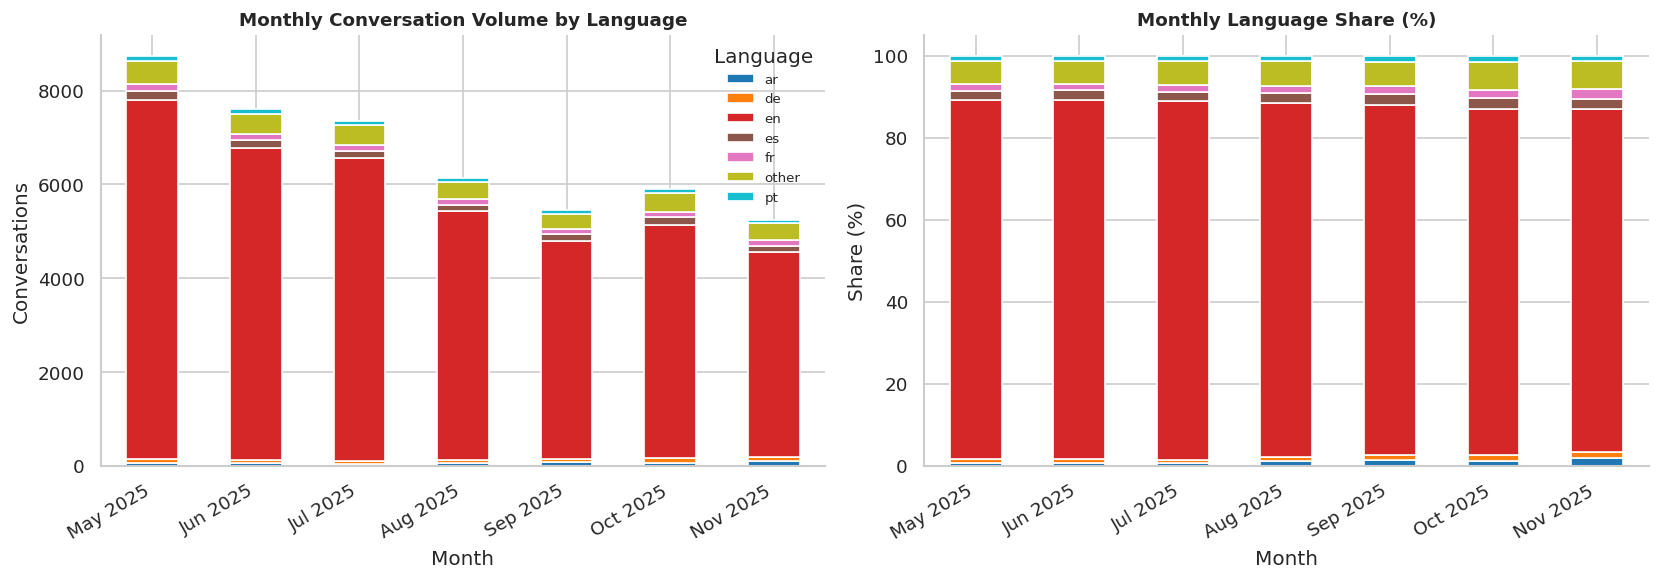


Language share per month (%):
lang_group   ar   de    en   es   fr  other   pt
month                                           
2025-05-01  0.7  1.0  87.6  2.1  1.8    5.6  1.3
2025-06-01  0.7  0.9  87.7  2.3  1.7    5.5  1.3
2025-07-01  0.6  0.8  87.6  2.0  1.7    5.9  1.3
2025-08-01  1.0  1.0  86.3  2.4  1.8    6.2  1.2
2025-09-01  1.4  1.1  85.4  2.7  2.0    5.9  1.5
2025-10-01  1.1  1.5  84.5  2.7  1.8    6.9  1.5
2025-11-01  1.8  1.6  83.7  2.4  2.3    6.9  1.2


In [9]:
df_lang = client.query(f"""
    SELECT month_start AS month, detected_language, conversation_count, pct_of_month
    FROM `{bq_table('language_trends')}`
    ORDER BY month_start, conversation_count DESC
""").to_dataframe()
df_lang['month'] = pd.to_datetime(df_lang['month'])

TOP_N_LANGS = 6
top_langs = df_lang.groupby('detected_language')['conversation_count'].sum().nlargest(TOP_N_LANGS).index.tolist()
df_lang['lang_group'] = df_lang['detected_language'].where(df_lang['detected_language'].isin(top_langs), other='other')

lang_pivot = df_lang.groupby(['month','lang_group'])['conversation_count'].sum().unstack(fill_value=0)
lang_share = lang_pivot.div(lang_pivot.sum(axis=1), axis=0).mul(100)
month_labels = [m.strftime('%b %Y') for m in lang_pivot.index]
assert len(month_labels) == len(lang_pivot), "Month label count mismatch"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lang_pivot.plot.bar(ax=axes[0], stacked=True, colormap='tab10')
axes[0].set_title('Monthly Conversation Volume by Language', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Conversations')
axes[0].set_xticklabels(month_labels, rotation=30, ha='right')
axes[0].legend(title='Language', fontsize=8, frameon=False)
sns.despine(ax=axes[0])

lang_share.plot.bar(ax=axes[1], stacked=True, colormap='tab10')
axes[1].set_title('Monthly Language Share (%)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Share (%)')
axes[1].set_xticklabels(month_labels, rotation=30, ha='right')
axes[1].get_legend().remove()  # remove duplicate legend; share legend shown in left panel
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'language_trend.png', bbox_inches='tight')
plt.show()
print('\nLanguage share per month (%):')
print(lang_share.round(1).to_string())


## Summary

In [10]:
print('TREND ANALYSIS SUMMARY')

monthly_vol = df_weekly.groupby('month')['total_conversations'].sum().reset_index()
monthly_vol['mom_pct'] = monthly_vol['total_conversations'].pct_change().mul(100).round(1)

print(f'\nData period: {df.conversation_date.min().date()} → {df.conversation_date.max().date()}')
print(f'  Total conversations: {len(df):,}  |  Clusters: {df_cluster_trends.cluster_id.nunique()}')

first_m = monthly_vol.iloc[0]
peak_m  = monthly_vol.loc[monthly_vol['total_conversations'].idxmax()]
last_m  = monthly_vol.iloc[-1]
peak_to_end_pct = 100 * (last_m.total_conversations - peak_m.total_conversations) / peak_m.total_conversations

print(f'\nVolume trajectory (conversations/month):')
print(f'  Start : {first_m.month.strftime("%b %Y")}  {int(first_m.total_conversations):>6,}  (partial week)')
print(f'  Peak  : {peak_m.month.strftime("%b %Y")}  {int(peak_m.total_conversations):>6,}  ← launch surge')
print(f'  End   : {last_m.month.strftime("%b %Y")}  {int(last_m.total_conversations):>6,}  ({peak_to_end_pct:+.0f}% from peak)')

print(f'\nAvg headline failure rate: {df_weekly.headline_failure_rate_pct.mean():.1f}%')
print(f'Avg escalation rate: {df_weekly.escalation_rate_pct.mean():.1f}%')

trends_file = RESULTS_DIR / 'cluster_trends.csv'
if trends_file.exists():
    tdf = pd.read_csv(trends_file)
    vol_col   = 'total_chunks' if 'total_chunks' in tdf.columns else 'total_convos'
    growing   = tdf[tdf['trend'].str.startswith('growing')]
    declining = tdf[tdf['trend'].str.startswith('declining')]
    stable    = tdf[tdf['trend'].str.startswith('stable')]
    print(f'\nTrend classification (OLS, |slope|>0.05 chunks/week, p<0.05, 31 weeks):')
    print(f'  Growing  ↑ : {len(growing):2d} clusters')
    print(f'  Declining↓ : {len(declining):2d} clusters')
    print(f'  Stable   → : {len(stable):2d} clusters')
    if len(declining):
        print(f'\nDeclining clusters:')
        print(declining[['cluster_id', vol_col, 'slope_per_week', 'p_value']].to_string(index=False))
    if len(growing):
        print(f'\nGrowing clusters:')
        print(growing[['cluster_id', vol_col, 'slope_per_week', 'p_value']].to_string(index=False))

print('\nAll charts saved to data/')

TREND ANALYSIS SUMMARY

Data period: 2025-05-01 → 2025-11-29
  Total conversations: 46,445  |  Clusters: 24

Volume trajectory (conversations/month):
  Start : Apr 2025     781  (partial week)
  Peak  : Jun 2025   8,883  ← launch surge
  End   : Nov 2025   5,100  (-43% from peak)

Avg headline failure rate: 7.6%
Avg escalation rate: 37.0%

Trend classification (OLS, |slope|>0.05 chunks/week, p<0.05, 31 weeks):
  Growing  ↑ :  0 clusters
  Declining↓ : 13 clusters
  Stable   → : 11 clusters

Declining clusters:
 cluster_id  total_chunks  slope_per_week  p_value
         10          4942          -0.242   0.0293
          9          4485          -0.251   0.0028
         19          3564          -0.253   0.0009
          3          4108          -0.306   0.0004
          4          4660          -0.342   0.0081
          5          4018          -0.351   0.0012
          8         10150          -0.360   0.0490
          1          5358          -0.431   0.0005
          2          7644